In [100]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np 

In [101]:
fashion_mnist = tf.keras.datasets.fashion_mnist.load_data()
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist
X_train, y_train = X_train_full[:-5000], y_train_full[:-5000]
X_valid, y_valid = X_train_full[-5000:], y_train_full[-5000:]

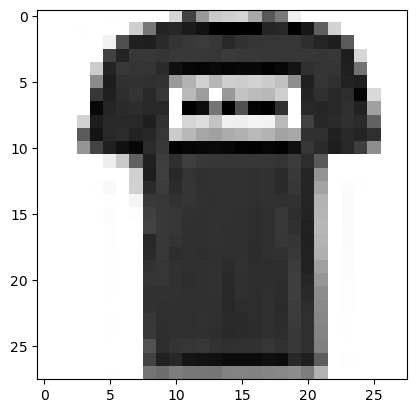

In [102]:
plt.imshow(X_train[1], cmap='binary')
plt.show()

In [103]:
X_train.shape 

(55000, 28, 28)

In [104]:
X_train, X_valid, X_test = X_train / 255., X_valid / 255., X_test / 255.

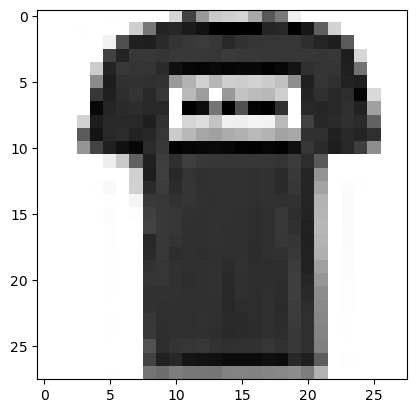

In [105]:
plt.imshow(X_train[1], cmap='binary')
plt.show()

In [106]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

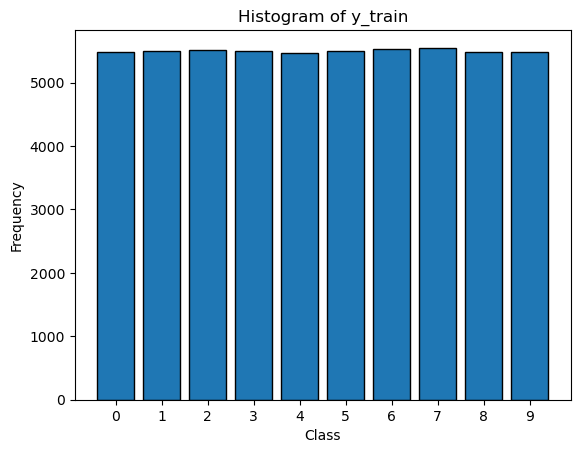

In [107]:
plt.hist(y_train, bins=np.arange(11)-0.5, edgecolor='black', rwidth=0.8)
plt.xticks(range(10))
plt.xlabel("Class")
plt.ylabel("Frequency")
plt.title("Histogram of y_train")
plt.show()

In [108]:
tf.keras.backend.clear_session() # to reset model numbering series

In [109]:
tf.random.set_seed(42)
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape = [28, 28]),
    tf.keras.layers.Dense(300, activation = 'relu'),
    tf.keras.layers.Dense(100, activation = 'relu'),
    tf.keras.layers.Dense(10, activation = 'softmax')
])

/Users/hendy/anaconda3/lib/python3.11/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [110]:
model.summary() # params include learnable weights + biases 

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [111]:
model.layers 

[<Flatten name=flatten, built=True>,
 <Dense name=dense, built=True>,
 <Dense name=dense_1, built=True>,
 <Dense name=dense_2, built=True>]

In [112]:
hidden1 = model.layers[1]

In [113]:
hidden1.name 

'dense'

In [114]:
model.get_layer('dense') is hidden1 

True

In [115]:
weights, biases = hidden1.get_weights()
weights.shape 

(784, 300)

In [116]:
biases.shape 

(300,)

In [117]:
model.compile(loss = 'sparse_categorical_crossentropy', optimizer = 'sgd', metrics = ['accuracy'])


In [118]:
history = model.fit(X_train, y_train, epochs = 30, validation_data=(X_valid, y_valid))

Epoch 1/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.6730 - loss: 1.0210 - val_accuracy: 0.8284 - val_loss: 0.5025
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8236 - loss: 0.5091 - val_accuracy: 0.8392 - val_loss: 0.4500
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8407 - loss: 0.4548 - val_accuracy: 0.8466 - val_loss: 0.4284
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 962us/step - accuracy: 0.8513 - loss: 0.4245 - val_accuracy: 0.8520 - val_loss: 0.4132
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8582 - loss: 0.4024 - val_accuracy: 0.8542 - val_loss: 0.4033
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8644 - loss: 0.3854 - val_accuracy: 0.8560 - val_loss: 0.3946
Epoch 7/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 962us/step - accuracy: 0.8682 - loss: 0.3712 - val_accuracy: 0.8584 - val_loss: 0.3871
Epoch 8/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 992us/step - accuracy: 0.8722 - loss: 0.3

In [121]:
print(list(history.history))
history.params 


['accuracy', 'loss', 'val_accuracy', 'val_loss']


{'verbose': 'auto', 'epochs': 30, 'steps': 1719}

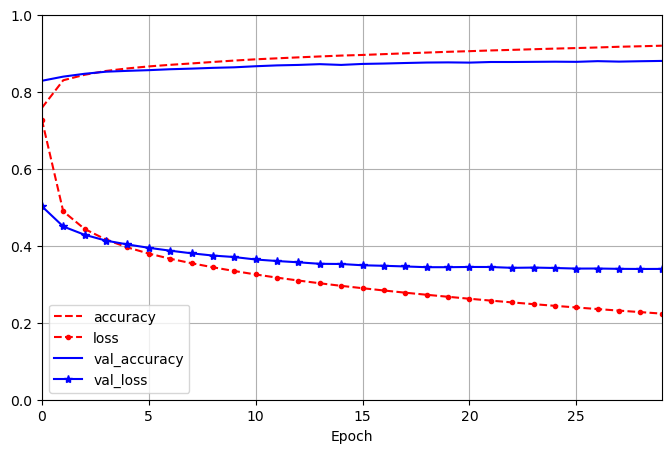

In [120]:
import matplotlib.pyplot as plt
import pandas as pd

pd.DataFrame(history.history).plot(
    figsize=(8, 5), xlim=[0, 29], ylim=[0, 1], grid=True, xlabel="Epoch",
    style=["r--", "r--.", "b-", "b-*"])
plt.show()

In [122]:
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 662us/step - accuracy: 0.8802 - loss: 0.3532


[0.35380518436431885, 0.8780999779701233]

In [123]:
X_new = X_test[:3]
y_proba = model.predict(X_new)
y_proba.round(2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step


array([[0.  , 0.  , 0.  , 0.  , 0.  , 0.06, 0.  , 0.  , 0.  , 0.94],
       [0.  , 0.  , 1.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 1.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ]],
      dtype=float32)

In [ ]:
indices = y_proba.argmax(axis=-1)
np.array(class_names)[indices] # advanced indexing 

array(['Ankle boot', 'Pullover', 'Trouser'], dtype='<U11')

In [1]:
import tensorflow as tf 
import matplotlib.pyplot as plt
import pandas as pd


In [2]:
mnist = tf.keras.datasets.mnist.load_data()
mnist 

((array([[[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         ...,
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0

In [12]:
(X_train, y_train), (X_test, y_test) = mnist 

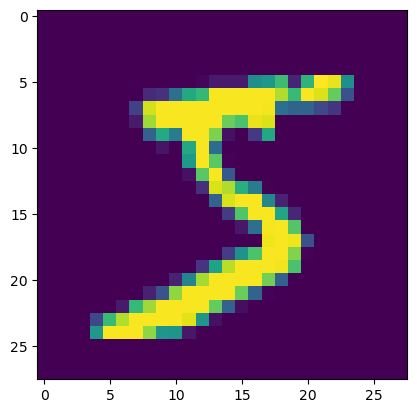

In [13]:
import matplotlib.pyplot as plt 
plt.imshow(X_train[0])

In [14]:
X_train.shape 

(60000, 28, 28)

In [15]:
X_train, X_test = X_train / 255., X_test / 255.

In [16]:
X_train, X_valid, y_train, y_valid = X_train[5000:], X_train[:5000],y_train[5000:], y_train[:5000] 

In [17]:
X_train.shape, X_valid.shape, y_train.shape, y_valid.shape 

((55000, 28, 28), (5000, 28, 28), (55000,), (5000,))

In [18]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=[28, 28]),
    tf.keras.layers.Dense(300, activation="relu"),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

In [24]:
from pathlib import Path
from time import strftime

def get_run_logdir(root_logdir="my_logs"):
    return Path(root_logdir) / strftime("run_%Y_%m_%d_%H_%M_%S")

run_logdir = get_run_logdir()

In [27]:
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint("my_mnist_model.keras", save_best_only=True)
early_stopping_cb = tf.keras.callbacks.EarlyStopping(patience=20)
tensorboard_cb = tf.keras.callbacks.TensorBoard(run_logdir,
                                                profile_batch=(100, 200))


2025-07-08 17:12:09.519614: I external/local_tsl/tsl/profiler/lib/profiler_session.cc:103] Profiler session initializing.
2025-07-08 17:12:09.521861: I external/local_tsl/tsl/profiler/lib/profiler_session.cc:118] Profiler session started.
2025-07-08 17:12:09.527383: I external/local_tsl/tsl/profiler/lib/profiler_session.cc:130] Profiler session tear down.


In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=[28, 28]),
    tf.keras.layers.Dense(300, activation="relu"),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])
optimizer = tf.keras.optimizers.SGD(learning_rate=3e-1) # 
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])
history = model.fit(X_train, y_train, epochs = 100, validation_data = (X_valid, y_valid), callbacks=[checkpoint_cb, early_stopping_cb, tensorboard_cb])


/Users/hendy/anaconda3/lib/python3.11/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
 200/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6666 - loss: 1.0105

2025-07-08 17:12:52.285986: I external/local_tsl/tsl/profiler/lib/profiler_session.cc:103] Profiler session initializing.
2025-07-08 17:12:52.286015: I external/local_tsl/tsl/profiler/lib/profiler_session.cc:118] Profiler session started.
2025-07-08 17:12:52.432369: I external/local_tsl/tsl/profiler/lib/profiler_session.cc:68] Profiler session collecting data.
2025-07-08 17:12:52.451234: I external/local_tsl/tsl/profiler/lib/profiler_session.cc:130] Profiler session tear down.
2025-07-08 17:12:52.456760: I external/local_xla/xla/tsl/profiler/rpc/client/save_profile.cc:147] Collecting XSpace to repository: my_logs/run_2025_07_08_17_09_18/train/plugins/profile/2025_07_08_17_12_52/Mohameds-MacBook-Air.local.xplane.pb


1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8689 - loss: 0.4109 - val_accuracy: 0.9702 - val_loss: 0.1056
Epoch 2/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9697 - loss: 0.0997 - val_accuracy: 0.9784 - val_loss: 0.0802
Epoch 3/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9812 - loss: 0.0603 - val_accuracy: 0.9794 - val_loss: 0.0755
Epoch 4/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9869 - loss: 0.0425 - val_accuracy: 0.9774 - val_loss: 0.0790
Epoch 5/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9911 - loss: 0.0299 - val_accuracy: 0.9772 - val_loss: 0.0919
Epoch 6/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9921 - loss: 0.0242 - val_accuracy: 0.9776 - val_loss: 0.0955
Epoch 7/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9918 - loss: 0.0228 - val_accuracy: 0.9788 - val_loss: 0.0972
Epoch 8/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9931 - loss: 0.0196 - val_

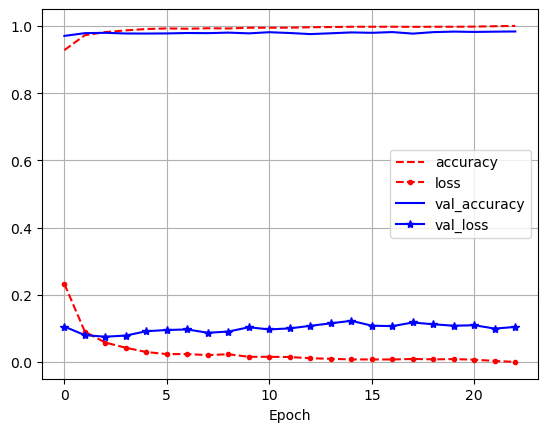

In [29]:
import matplotlib.pyplot as plt
import pandas as pd

pd.DataFrame(history.history).plot( grid=True, xlabel="Epoch",
    style=["r--", "r--.", "b-", "b-*"])
plt.legend()  
plt.show()

In [34]:
%load_ext tensorboard

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


In [32]:
%tensorboard --logdir=./my_logs

Reusing TensorBoard on port 6006 (pid 78201), started 0:00:16 ago. (Use '!kill 78201' to kill it.)

In [33]:
model = tf.keras.models.load_model("my_mnist_model.keras")
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 660us/step - accuracy: 0.9712 - loss: 0.0984


[0.07812703400850296, 0.9771999716758728]